# A Cartesian subspace normal

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/03-cartesian.ipynb)

`cartesian_subspace_kernel`: the sampling mask is the normal, so the
transfer is exact and lives on the image grid rather than on twice it.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "mrtoeplitz[nufft]",
            "matplotlib",
            "finufft",
        ],
        check=True,
    )

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n, rank = 96, 5
rng = np.random.default_rng(0)

# The same real fingerprinting basis and tissue signals the non-Cartesian
# example uses, so the coefficients carry the contrast they should.
local = Path("mrf_basis.npz")
if not local.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/FiRMLAB-Pisa/mrtoeplitz/main/"
        "examples/mrf_basis.npz",
        local,
    )
loaded = np.load(local)
basis = loaded["basis"][:, :rank]
tissue_signals, tissue_names = loaded["tissue_signals"], list(loaded["tissue_names"])
n_frames = basis.shape[0]

# Variable-density Cartesian sampling, a different draw every frame -- the
# Cartesian counterpart of one spoke per frame.
ky = np.abs(np.arange(n) - n // 2) / (n // 2)
probability = np.exp(-6.0 * ky**2) * 0.6 + 0.01
masks = np.stack(
    [
        np.repeat((rng.random(n) < probability)[:, None], n, axis=1).astype(np.float32)
        for _ in range(n_frames)
    ]
)

print(f"masks {masks.shape}, keeping {100 * masks.mean():.1f}% of each frame")
print(f"basis {basis.shape} (frames, rank), {n_frames} frames")

masks (500, 96, 96), keeping 22.6% of each frame
basis (500, 5) (frames, rank), 500 frames


## No gridding, and no doubled grid

A Cartesian encoding needs neither. `A_t = M_t F`, so the normal is
`F^H M_t F` — the sampling mask itself, applied in k-space. Two things follow:
the transfer is *exact* rather than accurate to a gridding tolerance, and it
lives on the image grid rather than on twice it.

The rank still costs `rank (rank + 1) / 2` entries per location, and the
packing and the apply are the same as the non-Cartesian case, so a solve does
not care which it was handed.

In [3]:
kernel = mt.cartesian_subspace_kernel(masks, basis)
print(kernel)
print(f"image {kernel.image_shape}, transfer on {kernel.spatial_shape}")

# A non-Cartesian transfer of the same image size, for the contrast.
angles = np.linspace(0, np.pi, 64, endpoint=False)
radius = np.linspace(-0.5, 0.5, 128, endpoint=False)
spokes = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)
gridded = mt.subspace_kernel(
    spokes, basis, (n, n), density=np.linalg.norm(spokes, axis=-1).astype(np.float32)
)
print(f"non-Cartesian of the same image: transfer on {gridded.spatial_shape}")

CompactToeplitzKernel(rank=5, image_shape=(96, 96), locations=9216, compression=3.23x)
image (96, 96), transfer on (96, 96)
non-Cartesian of the same image: transfer on (192, 192)


## Is it the Cartesian Gram?

The reference is the definition run frame by frame: expand the coefficients,
mask in k-space, transform back, project onto the basis.

In [4]:
def centered_fft(x, inverse=False):
    transform = np.fft.ifftn if inverse else np.fft.fftn
    return np.fft.fftshift(transform(np.fft.ifftshift(x), norm="ortho"))


def exact_cartesian_gram(coefficients):
    """The definition: expand, mask in k-space, project back."""
    out = np.zeros_like(coefficients)
    for frame in range(n_frames):
        expanded = sum(basis[frame, i] * coefficients[i] for i in range(rank))
        masked = centered_fft(expanded) * masks[frame]
        back = centered_fft(masked, inverse=True)
        for j in range(rank):
            out[j] += np.conj(basis[frame, j]) * back
    return out


# Coefficients from tissue signal evolutions, not one image scaled: each
# tissue projects onto the basis differently, so the components differ.
labels = phantom(n)
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
head = ((x / 0.69) ** 2 + (y / 0.92) ** 2) <= 1.0
compartments = {
    "fat": labels > 0.6,
    "grey matter": (labels > 0.25) & (labels <= 0.6),
    "white matter": (labels > 0.15) & (labels <= 0.25),
    "CSF": head & (labels <= 0.05),
}
coefficients = np.zeros((rank, n, n), dtype=np.complex64)
for name, mask in compartments.items():
    weights = tissue_signals[tissue_names.index(name)] @ basis.conj()
    coefficients[:, mask] = weights[:, None]

truth = exact_cartesian_gram(coefficients)
fast = kernel(torch.as_tensor(coefficients)[None])[0].numpy()
error = np.linalg.norm(fast - truth) / np.linalg.norm(truth)
print(f"relative error against the exact Cartesian Gram: {error:.2e}")
print("Exact, not approximate: there is no gridding to be accurate to.")

relative error against the exact Cartesian Gram: 1.55e-06
Exact, not approximate: there is no gridding to be accurate to.


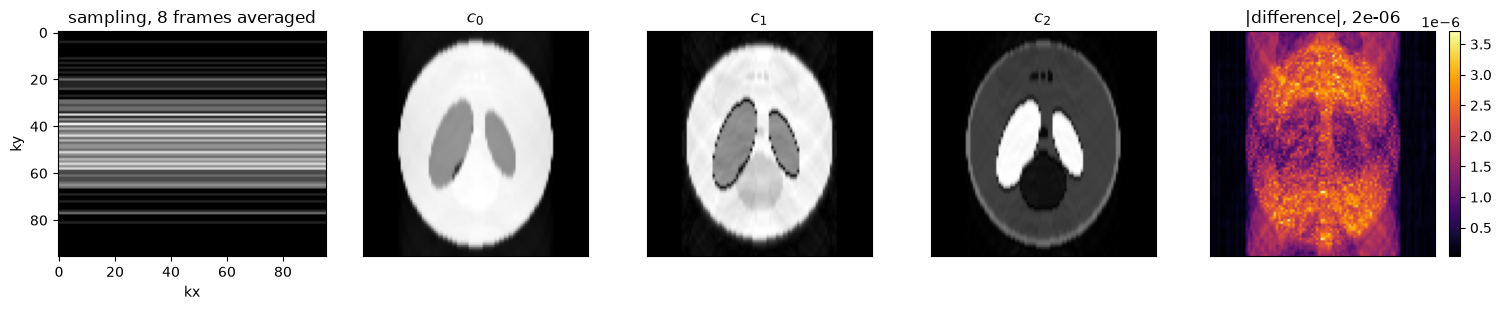

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
axes[0].imshow(masks[:8].mean(0), cmap="gray", aspect="auto")
axes[0].set_title("sampling, 8 frames averaged")
axes[0].set_xlabel("kx")
axes[0].set_ylabel("ky")
for index, component in enumerate((0, 1, 2)):
    panel = np.abs(fast[component])
    axes[index + 1].imshow(panel, cmap="gray", vmax=np.percentile(panel, 99.5))
    axes[index + 1].set_title(f"$c_{component}$")
    axes[index + 1].set_xticks([])
    axes[index + 1].set_yticks([])
shown = axes[4].imshow(
    np.abs(fast - truth).sum(0) / np.abs(truth).max(), cmap="inferno"
)
axes[4].set_title(f"|difference|, {error:.0e}")
axes[4].set_xticks([])
axes[4].set_yticks([])
fig.colorbar(shown, ax=axes[4], fraction=0.046)
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "cartesian.png", dpi=110, bbox_inches="tight")

## What the doubling would have cost

Same image, same rank, same basis — the only difference is where the samples
were taken.

In [7]:
for label, built in (("Cartesian", kernel), ("non-Cartesian", gridded)):
    print(
        f"{label:>14}: transfer grid {built.spatial_shape}, "
        f"{built.storage_nbytes / 2**20:6.2f} MiB stored, "
        f"{built.compression_ratio:.2f}x"
    )

cells_per_axis = np.prod(gridded.spatial_shape) / np.prod(kernel.spatial_shape)
print(
    f"\nthe doubled grid is {cells_per_axis:.0f}x the cells before anything is "
    "stored on it"
)

     Cartesian: transfer grid (96, 96),   1.09 MiB stored, 3.23x
 non-Cartesian: transfer grid (192, 192),   3.69 MiB stored, 3.81x

the doubled grid is 4x the cells before anything is stored on it
